# What the representation is actually worth, per label

`scripts/moments_baseline.py` asks how much of the probe's score was available with no
learned representation at all -- four arithmetic summaries of every DOF, fed to the
probe's own head. On `babel_action_60` the answer is uncomfortable: **moments 0.335,
attentive probe 0.378, finetune 0.395**. Under five points of macro mAP separating a
transformer pretrained for a hundred epochs from `mean`, `std`, `min`, `max`.

That single number is the wrong summary. A macro mAP averages 60 labels equally, so it
mixes labels no joint-angle model can read at all with labels four moments already read
perfectly -- and reports a small gap whichever way the representation is worth
something. This notebook decomposes it.

The finding, up front:

1. **27 of 60 labels give the representation nothing.** Ten are already saturated by
   summary statistics (`walk`, `jump`, `throw`); twelve sit at the floor for both arms
   (`swing body part`, `waist movements`, `grasp object`) and are probably not a
   function of joint angles at all.
2. **On the other 33 the representation is worth +0.112 macro mAP**, a third of the
   baseline again. Every large win is a rhythmic, repetitive or directional action --
   `punch`, `martial art`, `kick`, `dance` -- structure four moments over a 4 s window
   cannot express by construction.
3. **Finetuning adds +0.018 on one group and +0.016 on the other.** A flat calibration
   gain, not a fix for anything, which is why it reads as "finetuning does nothing".
4. **The window length is not the cause.** The obvious suspect -- a 4 s window diluting
   short actions past `label_min_coverage` -- is measured here and falsified.

Everything is a thin call into `scripts/label_analysis.py`, so the analysis reruns
headless and this notebook stays a viewer. Collection is cached to
`results/long/label_analysis.npz`; delete it or pass `force=True` to recollect.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

import polars as pl

sys.path.insert(0, "src")
from sometria.viz import project_root

# Run directories and the data paths inside each run's config are relative to the
# repository root; this notebook starts in notebooks/.
os.chdir(project_root())
sys.path.insert(0, "scripts")

from label_analysis import (
    GAP_THRESHOLD,
    build_cache,
    label_frame,
    plot_coverage_null,
    plot_gap_dumbbell,
    plot_group_summary,
    plot_ladder,
    plot_scatter,
)

data = build_cache()
frame = label_frame(data)
frame.head()

label,coverage,sequence,positives,moments,probe,finetune,gap,group
str,f64,f64,i64,f32,f32,f32,f32,str
"""punch""",0.910911,0.666667,30,0.270086,0.539616,0.514653,0.269529,"""earns"""
"""martial art""",0.880559,0.317073,41,0.155243,0.414336,0.471396,0.259093,"""earns"""
"""greet""",0.915044,0.819048,105,0.344636,0.583146,0.56155,0.23851,"""earns"""
"""scratch""",0.850452,0.727273,33,0.130073,0.322618,0.26161,0.192545,"""earns"""
"""crossing limbs""",0.68259,0.333333,24,0.228848,0.41784,0.507647,0.188991,"""earns"""


## 1. The ladder

Read every bar against the dashed line, not against zero. `moments k=50` is the strongest
statistics-only readout available -- kNN over the four moments, fitting nothing, using the
whole training set's geometry -- and it is the number a probe has to beat to have earned
its pretraining.

The random-init row is the same architecture with no pretraining, and it is the control
that says pretraining does *something*. It is not the control that says the task was hard.
The moments rows are.

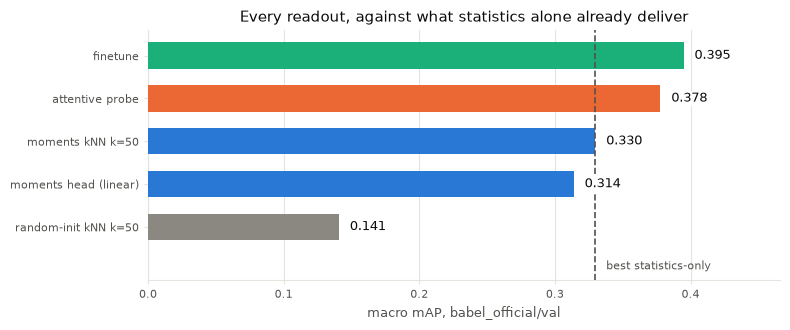

In [2]:
plot_ladder(data);

## 2. The decomposition

Split the vocabulary by whether the probe beat the moments head on that label by more than
`GAP_THRESHOLD` (0.03 AP -- a line drawn where the per-label noise sits, not a significance
test).

The left group is the number every results table reports. The right two are what it is an
average of. On the 33 labels where pretraining does anything at all it is worth +0.111
macro mAP over the moments (0.452 against 0.341); on the other 27 it is worth +0.006, and
those 27 drag the reported figure down from 0.452 to 0.378.

Note the finetune bar rises by the same amount in every group.

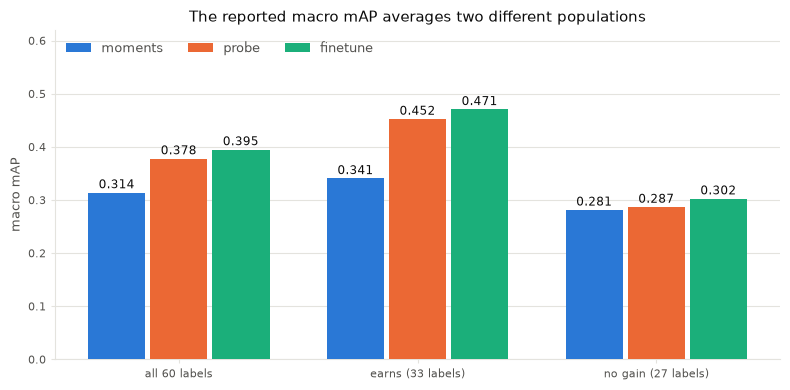

In [3]:
plot_group_summary(data);

In [ ]:
for group in ("earns", "no gain"):
    subset = frame.filter(pl.col("group") == group)
    print(
        f"{group:<8} {subset.height:>3} labels   "
        f"moments {subset['moments'].mean():.3f}   "
        f"probe {subset['probe'].mean():.3f}   "
        f"finetune {subset['finetune'].mean():.3f}   "
        f"finetune - probe {subset['finetune'].mean() - subset['probe'].mean():+.3f}"
    )

## 3. Every label at once

The diagonal is "pretraining bought nothing on this label". Height above it is the
representation's contribution in the units the metric is reported in; marker area is how
many positive windows the label has, so a point far above the line and small is a real
effect on a thin slice.

Points *below* the line are labels the four moments read better than the transformer.

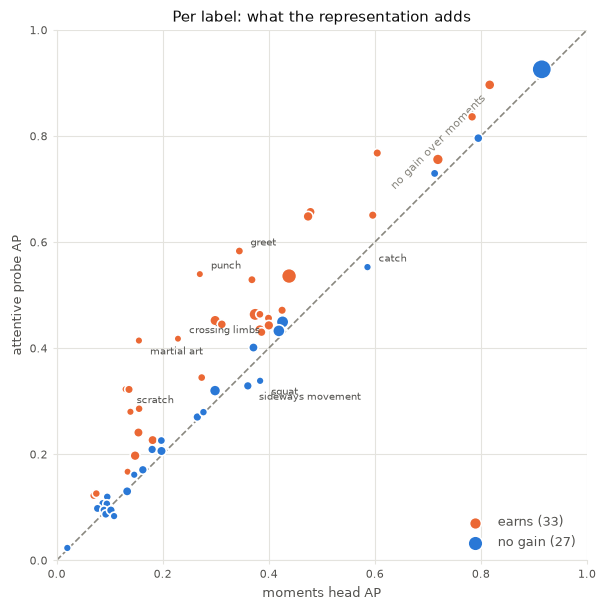

In [4]:
plot_scatter(data);

### The two ends, named

Top half: rhythm, repetition, direction. A `punch` and a `wave` have the same joint-angle
range and the same mean -- they differ in what happens in which order, which is exactly
what `mean`/`std`/`min`/`max` over a 4 s window throws away. This is the representation
doing real temporal work.

Bottom half splits in two, and the split matters:

- **saturated** (10 labels, probe AP > 0.30) -- `walk` 0.926 vs 0.916, `jump` 0.796 vs
  0.790, `throw` 0.729 vs 0.705, plus `catch`, `squat` and `sideways movement` where the
  moments win outright. Posture and range-of-motion labels. Nothing left to take.
- **at the floor** (12 labels, probe AP < 0.20) -- `swing body part` 0.023,
  `waist movements` 0.083, `head movements` 0.087, `exercise/training` 0.094. Near zero
  for a transformer and for four numbers alike. Either the category is too vague to be a
  function of joint angles (`poses`, `waist movements`), or it needs the object and scene
  that mocap does not contain (`grasp object`, `play sport`).

Only the second kind is a problem worth attacking, and attacking it means changing the
label set, not the model.

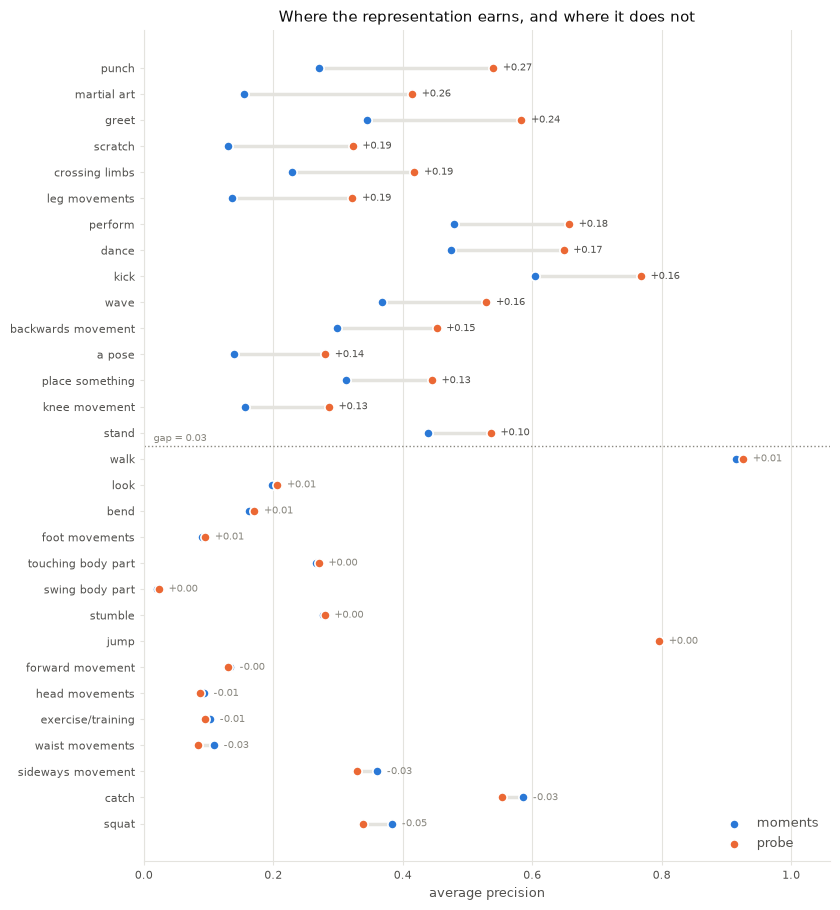

In [5]:
plot_gap_dumbbell(data, top=15);

## 4. The hypothesis this kills

A 4 s window with `label_min_coverage: 0.15` means a category needs 0.6 s to count as
present. The median in-vocabulary segment is 1.29 s and 89% are shorter than the window,
so the obvious suspect for the ceiling is dilution: short actions buried in a window of
other motion, thresholded into targets nothing can learn.

Measured, it is not what is happening. The correlation between a label's mean window
coverage and its gap is weakly **positive** -- the representation pulls *further* ahead
on labels that fill the window -- and the bucket means are lowest in the middle. Only
three labels sit below 0.45 mean coverage at all, so the effect has almost no mass to
act on.

Worth keeping the plot in the deck: it is the cheapest way to stop the question being
asked again.

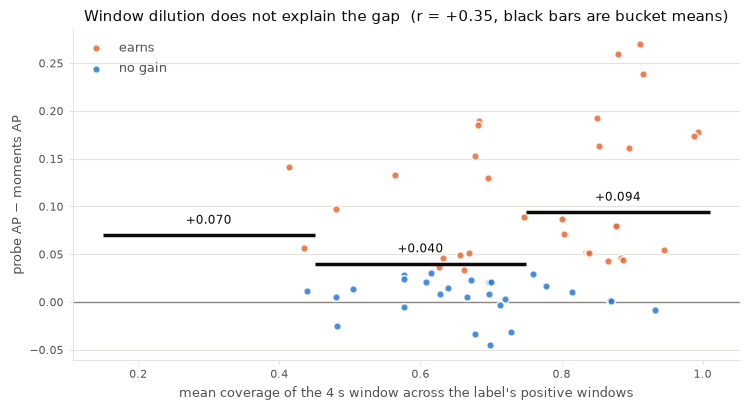

In [6]:
plot_coverage_null(data);

## 5. The table

Sorted by gap. `coverage` is the mean fraction of the 4 s window a label's positives
occupy; `sequence` is the share of them coming from a BABEL sequence annotation, which
spans the whole take and therefore needs no localization to predict.

In [7]:
with pl.Config(tbl_rows=-1, tbl_width_chars=140):
    display(frame)

label,coverage,sequence,positives,moments,probe,finetune,gap,group
str,f64,f64,i64,f32,f32,f32,f32,str
"""punch""",0.910911,0.666667,30,0.270086,0.539616,0.514653,0.269529,"""earns"""
"""martial art""",0.880559,0.317073,41,0.155243,0.414336,0.471396,0.259093,"""earns"""
"""greet""",0.915044,0.819048,105,0.344636,0.583146,0.56155,0.23851,"""earns"""
"""scratch""",0.850452,0.727273,33,0.130073,0.322618,0.26161,0.192545,"""earns"""
"""crossing limbs""",0.68259,0.333333,24,0.228848,0.41784,0.507647,0.188991,"""earns"""
"""leg movements""",0.681662,0.253731,134,0.136591,0.32217,0.23809,0.185579,"""earns"""
"""perform""",0.99295,0.970085,234,0.478698,0.656833,0.708945,0.178135,"""earns"""
"""dance""",0.987465,0.899654,289,0.474214,0.64839,0.68784,0.174176,"""earns"""
"""kick""",0.852552,0.725926,135,0.604612,0.767915,0.841283,0.163303,"""earns"""


## What follows from this

1. **Report the two subsets separately.** `val/macro_map` over all 60 measures the label
   ontology as much as the model. A `macro_map` restricted to the 33 changes the headline
   from "+0.06 over summary statistics" to "+0.11", which is the thing that was actually
   built.
2. **Find out whether the nine floor labels are noise or difficulty.** Fit the attentive
   head on the validation set itself and read in-sample AP: if it cannot fit
   `waist movements` while memorizing, the target is annotator noise and the label should
   leave the vocabulary rather than be chased. One short run, and it decides whether
   `babel_action_60` is the right benchmark at all.
3. **Segmentation is the readout that should show a large margin.** The 33 labels the
   representation is good at are the ones defined by *when* things happen, and
   `config/experiment_segmentation.yaml` scores exactly that. The `window` arm of
   `scripts/moments_baseline.py` has `boundary_f1s` identically 0 by construction, so it
   is also the one comparison the moments baseline cannot follow.